https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [2]:
import pandas as pd
import numpy as np

# 1.0 Leitura dos dados

In [3]:
df = pd.read_csv('creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2.0 Pré-processamento

## 2.1 Checagem de valores nulos

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.919560e-15,5.688174e-16,-8.769071e-15,2.782312e-15,-1.552563e-15,2.010663e-15,-1.694249e-15,-1.927028e-16,-3.137024e-15,...,1.537294e-16,7.959909e-16,5.367590e-16,4.458112e-15,1.453003e-15,1.699104e-15,-3.660161e-16,-1.206049e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# 3.0 Analise de dados

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

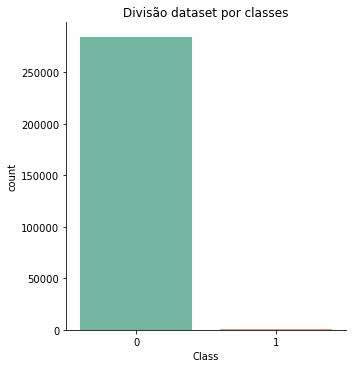

In [8]:
%matplotlib inline
sns.catplot(x="Class", kind="count", palette="Set2", data= df).set(title="Divisão dataset por classes")

In [9]:
#Contando quantos registros de fraudes existem:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

Os dados são altamente desbalanceados, a base possui 284315 registros comuns e 492 registros de fraudes. Será necessário aplicar técnicas para o balanceamento.

## 3.1 Histogramas

[Text(0.5, 1.0, 'Histograma de Tempo')]

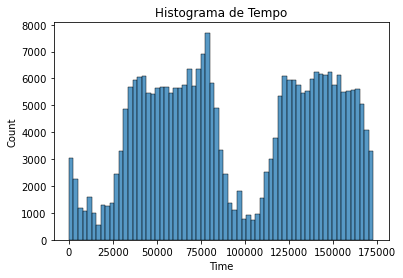

In [10]:
sns.histplot(data = df, x = "Time").set(title="Histograma de Tempo")

### 3.1.1 Histogramas por features

In [11]:
features = df.drop(columns=["Class"]).columns
features

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [12]:
numero_plots = len(features)
numero_plots

30

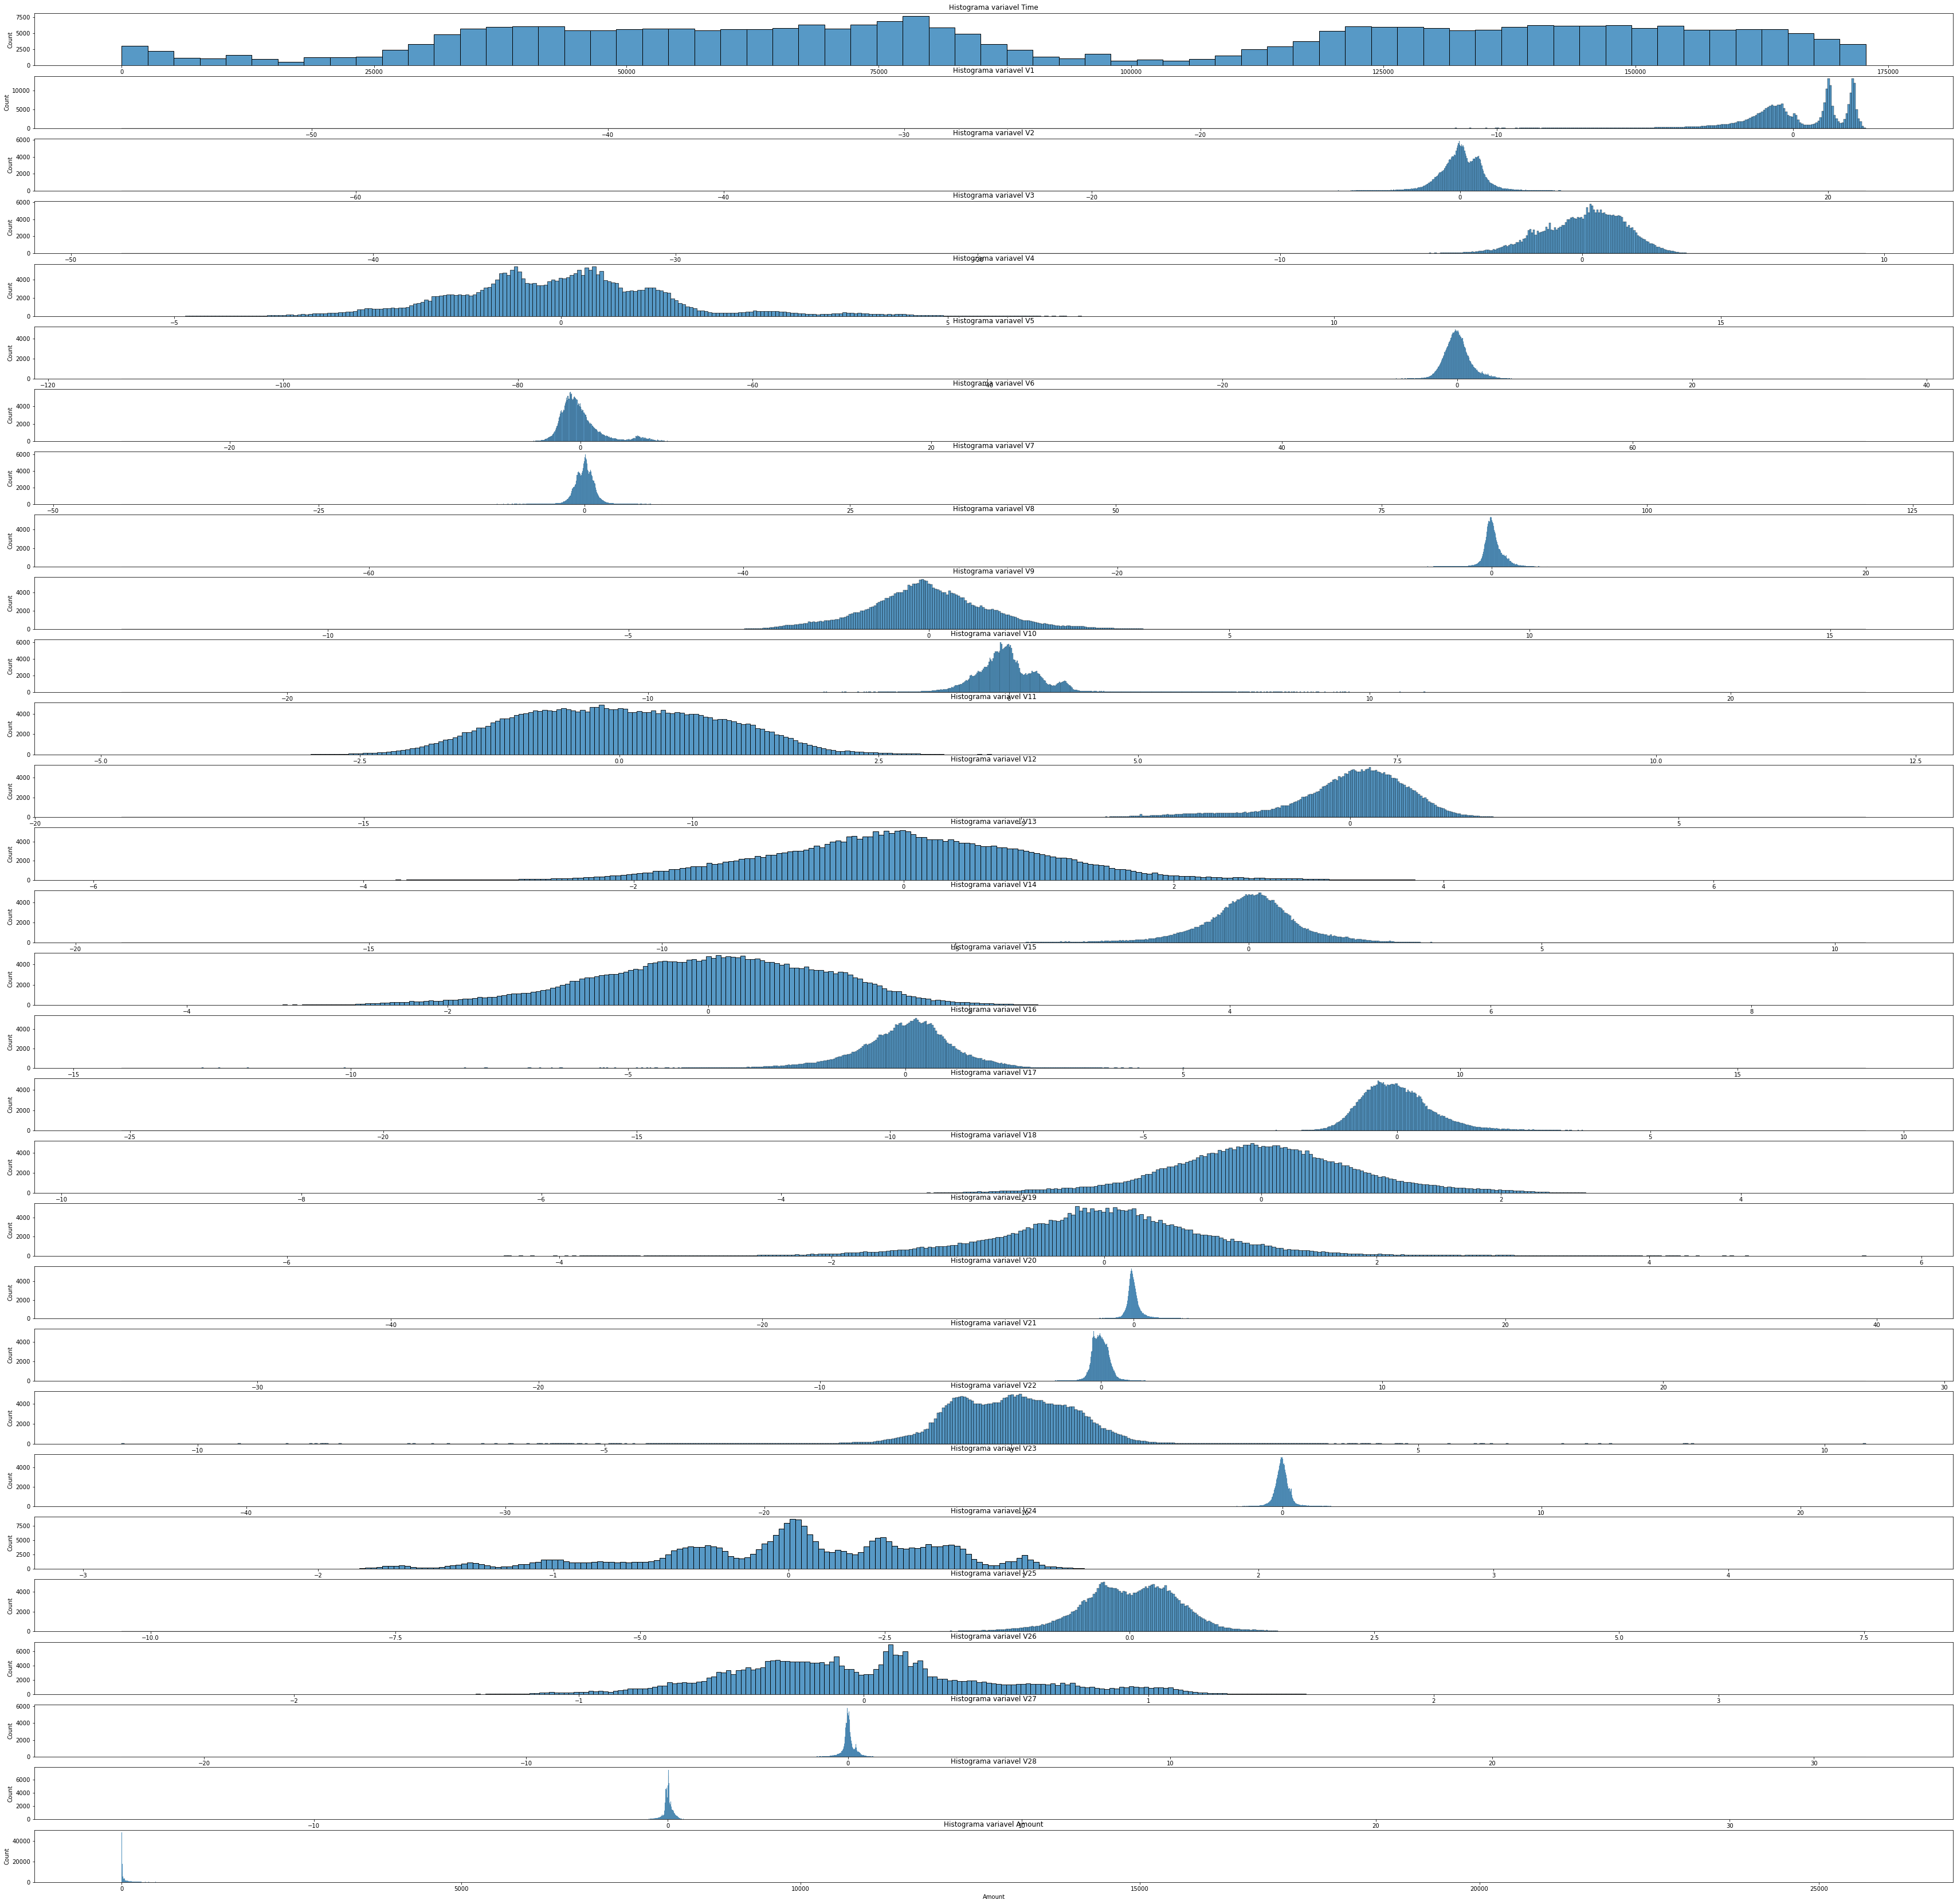

In [47]:
fig, axs = plt.subplots(nrows=numero_plots, figsize = (60,60))

k=0
for i in features:
    sns.histplot(data = df, x = i, ax=axs[k]).set(title="Histograma" + " variavel " + i)
    k = k+1
    


A maioria das distribuições não são normais, além disso a escala varia muito de feature pra feature e isso pode afetar o desempenho de algorítmos que utilizam distância para classificar fraudes de transações normais. A fim de otimizar a performance dos algorítmos de Machine Learning iremos aplicar técnicas para aproximar os dados á uma distribuição normal e iremos padronizá-los com média = 0 e desvio padrão = 1)

# 4 Teste de normalidade

In [13]:
len(df)

284807

Há cerca de 284807 registros, checaremos se é possível aplicar testes de normalidade considerando todos os registros com os

- Testes de Shapiro, Testes de D'Agostinho e Teste de Anderson
- Definimos valor de alfa = 0.05 para ter 95% de nivel de confiança

## 4.1 Shapiro Wilk

In [35]:
from scipy.stats import shapiro

In [57]:
_, p = shapiro(df['V1'])
p

0.0

In [ ]:
alpha = 0.05
if p > alpha:
  print('Distribuição normal')
else:
  print('Distribuição não normal')

## 4.2 D'Agostinho

In [256]:
from scipy.stats import normaltest

In [66]:
_, p = normaltest(df['V1'])
p

0.0

In [ ]:
alpha = 0.05
if p > alpha:
  print('Distribuição normal')
else:
  print('Distribuição não normal')

## 4.3 Anderson

In [67]:
from scipy.stats import anderson

In [68]:
anderson(df['V1']).statistic

7053.7524257128825

In [ ]:
alpha = 0.05
if p > alpha:
  print('Distribuição normal')
else:
  print('Distribuição não normal')

Os testes de normalidade não performam bem quando há muitos registros, como a base de dados é desbalanceada, optaremos por técnicas de balanceamento. Com os dados balanceados (50% de cada classe) será atingido cerca de 1000 registros. 

Após o balanceamento aplicaremos as técnicas para aproximar os dados para uma distribuição normal seguido da sua padronização para media = 0 e desvio padrão = 1

## 4.4 Testes D'Agostinho com dados aleatórios 1500 registros

In [33]:
from scipy import stats
rng = np.random.default_rng()
pts = 1500
a = rng.normal(0, 1, size=pts)
b = rng.normal(2, 1, size=pts)
x = np.concatenate((a, b))
k2, p = stats.normaltest(x)
alpha = 0.05
print("p = {:g}".format(p))
if p < alpha:  # null hypothesis: x comes from a normal distribution
    print("The null hypothesis can be rejected")
else:
    print("The null hypothesis cannot be rejected")

p = 1.01382e-18
The null hypothesis can be rejected


In [36]:
from scipy import stats
rng = np.random.default_rng()
pts = 1500
a = rng.normal(0, 1, size=pts)
b = rng.normal(2, 1, size=pts)
x = np.concatenate((a, b))
k2, p = shapiro(x)
alpha = 0.05
print("p = {:g}".format(p))
if p < alpha:  # null hypothesis: x comes from a normal distribution
    print("The null hypothesis can be rejected")
else:
    print("The null hypothesis cannot be rejected")

p = 9.00948e-06
The null hypothesis can be rejected


## 4.5 Balanceamento dos dados

In [284]:
from imblearn.under_sampling import NearMiss

In [333]:
X = df.drop(columns=['Class'])
y = df['Class']

In [334]:
nr = NearMiss()
X, y = nr.fit_resample(X, y)

In [335]:
X.shape, y.shape

((984, 30), (984,))

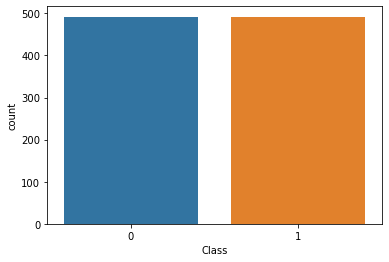

In [336]:
ax = sns.countplot(x=y)

## 4.6 Teste normalidade nos dados balanceados - Shapiro Wilk

In [337]:
features_normal = []
features_nao_normal = []
p_values_shapiro = []
p_values_dagostinho = []

for i in features:
    k2, p = shapiro(X[i])
    _, p2 = normaltest(X[i])
    p_values_shapiro.append(p)
    p_values_dagostinho.append(p2)
    
    alpha = 0.05
    
    if p < alpha:  # null hypothesis: x comes from a normal distribution
        features_nao_normal.append(i) ## "The null hypothesis can be rejected")
    else:
        features_normal.append(i) ##"The null hypothesis cannot be rejected")

In [338]:
len(features_nao_normal) , len(features_normal)

(29, 1)

In [339]:
df_p_values = pd.DataFrame(p_values_shapiro, columns = ['p_value'])
df_p_values.describe()

,p_value
count,3.000000e+01
mean,2.738417e-03
std,1.499893e-02
min,0.000000e+00
25%,1.332542e-36
50%,3.240918e-31
75%,8.585663e-21
max,8.215252e-02


In [340]:
features_normal

['V13']

A única feature que contem dados distribuidos numa Gaussiana é a V13, aplicaremos 3 técnicas para normalizar as outras 29 features não normais a fim de aproximarmos de uma normal e aumentar a performance dos algorítmos de ML

# 5 INVESTIGAÇÃO APENAS - (NAO APLICAR) - Técnicas para aproximação de distribuições normais

Fonte: https://towardsdatascience.com/transforming-skewed-data-73da4c2d0d16

## 5.1 Escalando os dados

In [192]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,76866.0,1.257227,0.408096,0.319266,0.685011,-0.302937,-1.052552,0.136991,-0.245655,-0.079491,...,-0.033053,-0.279430,-0.770134,0.119789,0.360130,0.241921,0.092261,-0.018228,0.032361,1.78
1,76868.0,1.254775,0.375340,0.311959,0.691077,-0.343494,-1.065252,0.110222,-0.222721,-0.017278,...,-0.057911,-0.283275,-0.803506,0.124643,0.354395,0.226835,0.093208,-0.021100,0.031686,2.69
2,76870.0,-1.050697,1.500753,0.846326,-0.282956,0.059866,-0.561182,0.484517,0.181547,0.081544,...,0.457988,-0.335560,-0.780232,-0.027029,-0.090180,-0.022896,0.091830,0.547241,0.278780,1.29
3,76866.0,1.245537,0.419648,0.312943,1.111459,-0.205612,-0.950912,0.267398,-0.274685,-0.127708,...,-0.098066,0.035687,0.186705,-0.107300,0.417887,0.712330,-0.330843,0.018576,0.021871,3.99
4,76870.0,1.261137,0.304662,0.527018,0.612765,-0.411488,-0.972770,0.112838,-0.248052,-0.068454,...,-0.044989,-0.249081,-0.683649,0.126936,0.395307,0.243448,0.092344,-0.024149,0.020589,1.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
980,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
981,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
982,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00


In [193]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,90393.878049,-2.382994,2.115600,-3.519994,2.296550,-1.459575,-0.788125,-2.797100,0.295290,-1.296937,...,0.185891,0.309421,-0.008665,-0.026530,-0.030337,0.031152,0.022708,0.087085,0.046227,65.352470
std,47778.797490,5.503503,3.497487,6.216836,3.169148,4.227923,1.667629,5.833749,4.890868,2.327313,...,1.041477,2.801522,1.168185,1.167412,0.560434,0.663162,0.429865,1.020747,0.425555,190.196997
min,406.000000,-30.552380,-8.402154,-31.103685,-4.067605,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-4.128186,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-2.085605,0.000000
25%,53709.750000,-2.871640,0.189965,-5.084967,-0.031784,-1.638023,-1.566318,-3.094485,-0.187299,-2.331368,...,-0.198984,-0.225145,-0.583333,-0.216472,-0.379825,-0.305045,-0.270092,-0.054257,-0.053800,1.000000
50%,77183.500000,-0.732607,1.131643,-1.446699,1.314843,-0.241534,-0.733544,-0.628802,0.158687,-0.650814,...,-0.012592,0.101741,-0.010150,-0.028799,0.025828,0.058301,0.027553,0.060864,0.035125,7.645000
75%,143449.250000,1.080413,2.936794,0.372924,4.229802,0.616558,-0.097443,0.276551,0.912601,0.116000,...,0.388452,0.612836,0.546494,0.182499,0.385643,0.416734,0.280840,0.466568,0.226970,23.605000
max,170348.000000,2.313171,22.057729,3.541039,12.114672,11.095089,6.474115,5.802537,20.007208,6.472920,...,11.059004,27.202839,8.361985,5.466230,3.261279,2.208209,2.745261,3.052358,1.779364,2125.870000


há dados negativos, não podemos aplicar logarítmo direto, vamos escalar todas features em um range entre 0 e 1

In [162]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
    
for i in features:
    
    transformados = X[i].to_numpy()
    transformados = transformados.reshape(-1,1)
    
    dados = scaler.fit_transform(transformados)
    X[i] = dados

In [163]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.449918,0.967871,0.289241,0.907005,0.293693,0.656692,0.415649,0.885219,0.668266,0.670849,...,0.269644,0.450359,0.470571,0.783725,0.451506,0.718692,0.319383,0.702343,0.547990,0.000837
1,0.449930,0.967796,0.288166,0.906794,0.294068,0.655471,0.414663,0.884677,0.668641,0.673974,...,0.268007,0.450283,0.468636,0.783921,0.450422,0.716534,0.319626,0.702064,0.547816,0.001265
2,0.449942,0.897648,0.325113,0.922219,0.233876,0.667620,0.453798,0.892260,0.675263,0.678938,...,0.301976,0.449237,0.469986,0.777786,0.366370,0.680806,0.319272,0.757158,0.611748,0.000607
3,0.449918,0.967515,0.289620,0.906823,0.320045,0.659624,0.423540,0.887861,0.667790,0.668427,...,0.265363,0.456662,0.526043,0.774539,0.462426,0.785992,0.210837,0.705910,0.545276,0.001877
4,0.449942,0.967990,0.285845,0.913002,0.289228,0.653423,0.421843,0.884730,0.668226,0.671403,...,0.268858,0.450966,0.475585,0.784014,0.458157,0.718911,0.319404,0.701769,0.544945,0.000842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,0.992903,0.870957,0.312799,0.767371,0.359461,0.618634,0.341277,0.864558,0.683710,0.571112,...,0.354322,0.471520,0.496714,0.804745,0.327669,0.760980,0.497973,0.732482,0.577902,0.183454
980,0.994110,0.971563,0.318174,0.753345,0.338608,0.679147,0.394377,0.853814,0.676360,0.618209,...,0.286710,0.463360,0.516856,0.772988,0.368097,0.758744,0.485421,0.741833,0.587907,0.000358
981,0.994133,0.909044,0.312822,0.833893,0.280301,0.632066,0.497106,0.837170,0.692111,0.642077,...,0.288148,0.470984,0.563576,0.786603,0.389483,0.578257,0.416575,0.741441,0.589905,0.036639
982,0.997752,0.834873,0.295077,0.741930,0.363651,0.640497,0.268837,0.837711,0.689631,0.592844,...,0.291987,0.467613,0.499612,0.760429,0.348697,0.637132,0.451210,0.789888,0.473977,0.115247


In [164]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,0.529521,0.857110,0.345299,0.796187,0.393279,0.621855,0.436178,0.825776,0.677126,0.609692,...,0.284060,0.462136,0.514717,0.777806,0.377684,0.688539,0.301539,0.712551,0.551578,0.030742
std,0.281148,0.167455,0.114823,0.179445,0.195841,0.127345,0.129470,0.118188,0.080111,0.116909,...,0.068576,0.056030,0.067725,0.047224,0.105956,0.094875,0.110280,0.098949,0.110106,0.089468
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.313658,0.842242,0.282080,0.751015,0.249398,0.616480,0.375761,0.819752,0.669222,0.557729,...,0.258718,0.451445,0.481401,0.770122,0.311610,0.640440,0.226422,0.698850,0.525698,0.000470
50%,0.451786,0.907326,0.312995,0.856032,0.332614,0.658542,0.440416,0.869705,0.674889,0.642149,...,0.270991,0.457983,0.514631,0.777714,0.388303,0.692423,0.302782,0.710010,0.548706,0.003596
75%,0.841718,0.962491,0.372258,0.908554,0.512747,0.684388,0.489801,0.888047,0.687238,0.680669,...,0.297398,0.468205,0.546902,0.786262,0.456330,0.743702,0.367762,0.749338,0.598343,0.011104
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Substituiremos simbolicamente os valores = 0 por valores = 0.01

In [166]:
for i in features:
    X[i] = X[i].apply(lambda x: x if x > 0 else 0.01)


In [167]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,0.529531,0.857120,0.345309,0.796198,0.393290,0.621865,0.436188,0.825787,0.677136,0.609702,...,0.284070,0.462147,0.514778,0.777816,0.377695,0.688549,0.301549,0.712592,0.551588,0.031107
std,0.281129,0.167403,0.114793,0.179401,0.195820,0.127295,0.129437,0.118118,0.080025,0.116857,...,0.068535,0.055947,0.067264,0.047058,0.105920,0.094802,0.110253,0.098658,0.110055,0.089362
min,0.000388,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.005722,...,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.000705,0.010000,0.010000,0.000005
25%,0.313658,0.842242,0.282080,0.751015,0.249398,0.616480,0.375761,0.819752,0.669222,0.557729,...,0.258718,0.451445,0.481401,0.770122,0.311610,0.640440,0.226422,0.698850,0.525698,0.000546
50%,0.451786,0.907326,0.312995,0.856032,0.332614,0.658542,0.440416,0.869705,0.674889,0.642149,...,0.270991,0.457983,0.514631,0.777714,0.388303,0.692423,0.302782,0.710010,0.548706,0.004229
75%,0.841718,0.962491,0.372258,0.908554,0.512747,0.684388,0.489801,0.888047,0.687238,0.680669,...,0.297398,0.468205,0.546902,0.786262,0.456330,0.743702,0.367762,0.749338,0.598343,0.011104
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 5.2 Aplicando logarítmo para aproximação de uma normal

In [168]:
for i in features:
    dados = np.log(X[i])
    X[i] = dados


In [169]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,9.840000e+02,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,9.840000e+02,984.000000,...,984.000000,984.000000,9.840000e+02,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,-8.612988e-01,-0.196440,-1.111895,-0.285491,-1.058581,-0.518362,-0.882935,-0.210240,-4.080964e-01,-0.524275,...,-1.288390,-0.781970,-6.871356e-01,-0.256658,-1.027218,-0.386466,-1.287395,-0.361986,-0.625798,-5.513024
std,8.100441e-01,0.380020,0.324054,0.449278,0.518591,0.376783,0.361508,0.248036,2.652574e-01,0.303574,...,0.270912,0.182987,3.225798e-01,0.156641,0.373607,0.199330,0.503442,0.311166,0.298269,2.035377
min,-7.853558e+00,-4.605170,-4.605170,-4.605170,-4.605170,-4.605170,-4.605170,-4.605170,-4.605170e+00,-5.163403,...,-4.605170,-4.605170,-4.605170e+00,-4.605170,-4.605170,-4.605170,-7.257183,-4.605170,-4.605170,-12.267107
25%,-1.159451e+00,-0.171688,-1.265565,-0.286329,-1.388707,-0.483730,-0.978801,-0.198754,-4.016400e-01,-0.583883,...,-1.352016,-0.795301,-7.310550e-01,-0.261206,-1.166003,-0.445599,-1.485353,-0.358319,-0.643029,-7.513973
50%,-7.945456e-01,-0.097253,-1.161568,-0.155448,-1.100774,-0.417727,-0.820036,-0.139601,-3.932075e-01,-0.442935,...,-1.305669,-0.780924,-6.643056e-01,-0.251396,-0.945969,-0.367559,-1.194742,-0.342477,-0.600193,-5.465824
75%,-1.723102e-01,-0.038231,-0.988167,-0.095901,-0.667974,-0.379231,-0.713756,-0.118731,-3.750753e-01,-0.384679,...,-1.212684,-0.758850,-6.034860e-01,-0.240466,-0.784539,-0.296115,-1.000319,-0.288565,-0.513592,-4.500513
max,-1.110223e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.110223e-16,0.000000,...,0.000000,0.000000,-1.110223e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 5.4 Novos testes de normalidade

In [181]:
features_normal2 = []
features_nao_normal2 = []
p_values2 = []

for i in features:
    k2, p = shapiro(X[i])
    p_values2.append(p)
    alpha = 0.05
    
    if p < alpha:  # null hypothesis: x comes from a normal distribution
        features_nao_normal2.append(i) ## "The null hypothesis can be rejected")
    else:
        features_normal2.append(i) ##"The null hypothesis cannot be rejected")

In [182]:
len(features_nao_normal) , len(features_normal), len(features_nao_normal2) , len(features_normal2)

(29, 1, 30, 0)

In [183]:
df_p_values2 = pd.DataFrame(p_values2, columns = ['p_value'])
df_p_values.mean(), df_p_values.std(), df_p_values2.mean(), df_p_values2.std()

(p_value    0.002738
 dtype: float64,
 p_value    0.014999
 dtype: float64,
 p_value    9.100407e-14
 dtype: float64,
 p_value    4.809136e-13
 dtype: float64)

Não se justifica a aplicação de toda a etapa 5, uma vez que os p_values após todo o processamento da etapa 5 foram menores com relação aos p_values anterior ao processamento.

Na prática, quanto menor o p_value maior é a certeza da rejeição da hipotese nula (H0), em resumo maior a certeza que os dados não estão em uma normal.

Dessa forma, utilizaremos os dados sem aplicar o processamento realizado no tópico 5.

# 6.0 Aproximando a distribuição das variaveis Amount e Time para uma normal

In [342]:
df_p_values

,p_value
0,5.550787e-23
1,4.530249e-39
2,1.376172e-33
3,2.204106e-36
4,1.129415e-20
5,3.572185e-37
6,6.146459e-19
7,3.474351e-40
8,1.401298e-45
9,1.441969e-24


Como podemos observar a primeira e ultima feature apresenta um p_value muito baixo, iremos reprocessá-los a fim de aproximar os dados á uma normal.

Faremos isso para as features Time e Ammount uma vez são as que possuem uma escala maior com relação as outras.

In [355]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,90393.878049,-2.382994,2.115600,-3.519994,2.296550,-1.459575,-0.788125,-2.797100,0.295290,-1.296937,...,0.185891,0.309421,-0.008665,-0.026530,-0.030337,0.031152,0.022708,0.087085,0.046227,2.343834
std,47778.797490,5.503503,3.497487,6.216836,3.169148,4.227923,1.667629,5.833749,4.890868,2.327313,...,1.041477,2.801522,1.168185,1.167412,0.560434,0.663162,0.429865,1.020747,0.425555,1.764715
min,406.000000,-30.552380,-8.402154,-31.103685,-4.067605,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-4.128186,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-2.085605,0.000000
25%,53709.750000,-2.871640,0.189965,-5.084967,-0.031784,-1.638023,-1.566318,-3.094485,-0.187299,-2.331368,...,-0.198984,-0.225145,-0.583333,-0.216472,-0.379825,-0.305045,-0.270092,-0.054257,-0.053800,0.693147
50%,77183.500000,-0.732607,1.131643,-1.446699,1.314843,-0.241534,-0.733544,-0.628802,0.158687,-0.650814,...,-0.012592,0.101741,-0.010150,-0.028799,0.025828,0.058301,0.027553,0.060864,0.035125,2.156973
75%,143449.250000,1.080413,2.936794,0.372924,4.229802,0.616558,-0.097443,0.276551,0.912601,0.116000,...,0.388452,0.612836,0.546494,0.182499,0.385643,0.416734,0.280840,0.466568,0.226970,3.202917
max,170348.000000,2.313171,22.057729,3.541039,12.114672,11.095089,6.474115,5.802537,20.007208,6.472920,...,11.059004,27.202839,8.361985,5.466230,3.261279,2.208209,2.745261,3.052358,1.779364,7.662407


In [356]:
X['Amount2'] = np.log(X['Amount']+1)

In [357]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Amount2
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,90393.878049,-2.382994,2.115600,-3.519994,2.296550,-1.459575,-0.788125,-2.797100,0.295290,-1.296937,...,0.309421,-0.008665,-0.026530,-0.030337,0.031152,0.022708,0.087085,0.046227,2.343834,1.068303
std,47778.797490,5.503503,3.497487,6.216836,3.169148,4.227923,1.667629,5.833749,4.890868,2.327313,...,2.801522,1.168185,1.167412,0.560434,0.663162,0.429865,1.020747,0.425555,1.764715,0.533709
min,406.000000,-30.552380,-8.402154,-31.103685,-4.067605,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-2.085605,0.000000,0.000000
25%,53709.750000,-2.871640,0.189965,-5.084967,-0.031784,-1.638023,-1.566318,-3.094485,-0.187299,-2.331368,...,-0.225145,-0.583333,-0.216472,-0.379825,-0.305045,-0.270092,-0.054257,-0.053800,0.693147,0.526589
50%,77183.500000,-0.732607,1.131643,-1.446699,1.314843,-0.241534,-0.733544,-0.628802,0.158687,-0.650814,...,0.101741,-0.010150,-0.028799,0.025828,0.058301,0.027553,0.060864,0.035125,2.156973,1.149613
75%,143449.250000,1.080413,2.936794,0.372924,4.229802,0.616558,-0.097443,0.276551,0.912601,0.116000,...,0.612836,0.546494,0.182499,0.385643,0.416734,0.280840,0.466568,0.226970,3.202917,1.435777
max,170348.000000,2.313171,22.057729,3.541039,12.114672,11.095089,6.474115,5.802537,20.007208,6.472920,...,27.202839,8.361985,5.466230,3.261279,2.208209,2.745261,3.052358,1.779364,7.662407,2.158993


## 6.1 Validação normalidade - Amount

In [361]:
k2, p1 = shapiro(X['Amount'])
k2, p2 = shapiro(X['Amount2'])
p1,p2

(2.698438828005238e-23, 6.741993683779678e-16)

O valor de P aumentou, no entanto, ainda é maior que alfa, sendo assim embora a distribuição ainda não seja normal houve uma aproximação.

## 6.2 Validação normalidade - Time

In [362]:
X['Time2'] = np.log(X['Time']+1)

In [363]:
k2, p1 = shapiro(X['Time'])
k2, p2 = shapiro(X['Time2'])
p1,p2

(5.550786942973992e-23, 5.8759835782632965e-31)

O valor de P diminuiu, isso significa que os dados se afastaram de uma distribuição normal, dessa forma manteremos a variável time como está atualmente.

## 6.3 Alteração no dataframe

In [364]:
X['Amount'] = X['Amount2']

In [365]:
X = X.drop(columns=['Time2','Amount2'])

In [366]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,76866.0,1.257227,0.408096,0.319266,0.685011,-0.302937,-1.052552,0.136991,-0.245655,-0.079491,...,-0.033053,-0.279430,-0.770134,0.119789,0.360130,0.241921,0.092261,-0.018228,0.032361,0.704310
1,76868.0,1.254775,0.375340,0.311959,0.691077,-0.343494,-1.065252,0.110222,-0.222721,-0.017278,...,-0.057911,-0.283275,-0.803506,0.124643,0.354395,0.226835,0.093208,-0.021100,0.031686,0.835352
2,76870.0,-1.050697,1.500753,0.846326,-0.282956,0.059866,-0.561182,0.484517,0.181547,0.081544,...,0.457988,-0.335560,-0.780232,-0.027029,-0.090180,-0.022896,0.091830,0.547241,0.278780,0.603524
3,76866.0,1.245537,0.419648,0.312943,1.111459,-0.205612,-0.950912,0.267398,-0.274685,-0.127708,...,-0.098066,0.035687,0.186705,-0.107300,0.417887,0.712330,-0.330843,0.018576,0.021871,0.958367
4,76870.0,1.261137,0.304662,0.527018,0.612765,-0.411488,-0.972770,0.112838,-0.248052,-0.068454,...,-0.044989,-0.249081,-0.683649,0.126936,0.395307,0.243448,0.092344,-0.024149,0.020589,0.706084


# 7.0 Modelos de Machine Learning

In [367]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold

In [369]:
resultados_naive_bayes_cv = []
resultados_naive_bayes_cv_300 = []
resultados_forest_cv = []
resultados_forest_cv_300 = []

In [383]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [375]:
for i in range(30):
    kfold = KFold(n_splits = 10, shuffle = True, random_state = i)
  
    naive_bayes = GaussianNB()
    
    
    
    # Aplicação dos kfolds para avaliação estatística
    scores = cross_val_score(naive_bayes, X, y, cv = kfold)
    resultados_naive_bayes_cv_300.append(scores)
    resultados_naive_bayes_cv.append(scores.mean())
 
    # Aplicação dos kfolds para avaliação estatística
    random_forest = RandomForestClassifier()
    scores = cross_val_score(random_forest, X, y, cv = kfold)
    resultados_forest_cv_300.append(scores)
    resultados_forest_cv.append(scores.mean())

C:\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


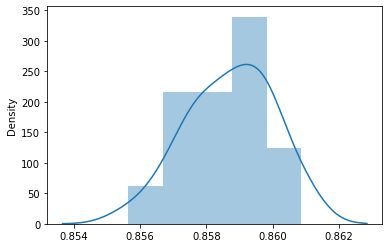

In [376]:
sns.distplot(resultados_naive_bayes_cv);

C:\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


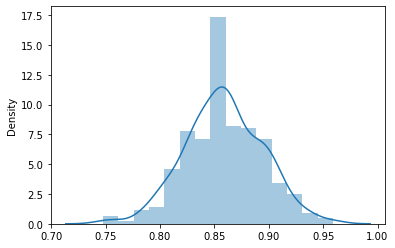

In [377]:
sns.distplot(resultados_naive_bayes_cv_300);

C:\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


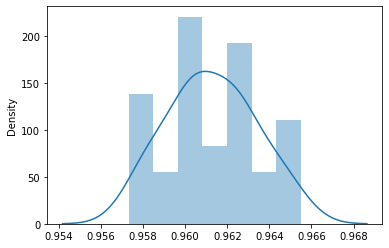

In [378]:
sns.distplot(resultados_forest_cv);

C:\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


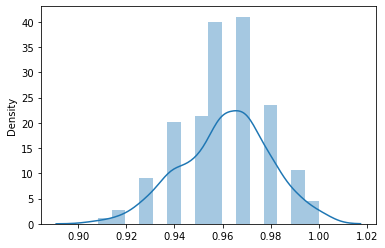

In [380]:
sns.distplot(resultados_forest_cv_300);

In [382]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("Test Data Score:\n",clf.score(X_test,y_test)*100)
print("")
print("DF Score:\n",clf.score(X_df,y_df)*100)
print("")
print("Classification Report Test:\n",classification_report(y_test,y_test_pred))
print("")
print("Classification DF:\n",classification_report(y_df,y_df_pred))
print("")
print("Confusion Matrix Test:\n",confusion_matrix(y_test,y_test_pred))
print("")
print("Confusion Matrix DF:\n",confusion_matrix(y_df,y_df_pred))
print("")

# Testes

In [385]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [386]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

In [387]:
print("Test Data Score:\n",clf.score(X_test,y_test)*100)
print("")
print("Classification Report Test:\n",classification_report(y_test,y_test_pred))
print("")
print("Confusion Matrix Test:\n",confusion_matrix(y_test,y_test_pred))

Test Data Score:
 95.94594594594594

Classification Report Test:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       148
           1       0.99      0.93      0.96       148

    accuracy                           0.96       296
   macro avg       0.96      0.96      0.96       296
weighted avg       0.96      0.96      0.96       296


Confusion Matrix Test:
 [[147   1]
 [ 11 137]]


# Multi-metric evaluation on cross_val_score and GridSearchCV

In [398]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

In [395]:
recall_1 = make_scorer(recall_score)

In [396]:
scoring = {"AUC": "roc_auc", "Recall": recall_1}

In [403]:
gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"min_samples_split": range(2, 403, 20)},
    scoring=scoring,
    refit="Recall",
    n_jobs=2,
    return_train_score=True,
)

In [412]:
gs.fit(X_train, y_train)
results = gs.cv_results_

In [413]:
results

{'mean_fit_time': array([0.01479759, 0.01093564, 0.01249976, 0.01249886, 0.00937448,
        0.00937529, 0.01149025, 0.00937262, 0.01012182, 0.01619778,
        0.01219902, 0.01379709, 0.00652356, 0.01257038, 0.00937557,
        0.0092577 , 0.00859776, 0.00938396, 0.00779767, 0.00619516,
        0.00764499]),
 'std_fit_time': array([0.00159969, 0.00559876, 0.00624988, 0.00624943, 0.00765423,
        0.00765489, 0.00691146, 0.00765271, 0.005449  , 0.00453436,
        0.00231388, 0.00231269, 0.00600351, 0.00378793, 0.00765512,
        0.01055188, 0.0027272 , 0.00284183, 0.00075048, 0.00074927,
        0.00401728]),
 'mean_score_time': array([0.00920429, 0.00513797, 0.00312448, 0.00937538, 0.01562452,
        0.01562619, 0.00692921, 0.01124687, 0.00340157, 0.00920234,
        0.0086009 , 0.00940042, 0.00805221, 0.00168962, 0.00312576,
        0.01230516, 0.01040187, 0.01120062, 0.00940127, 0.00620022,
        0.00219989]),
 'std_score_time': array([1.16570845e-03, 6.00587086e-03, 6.248950

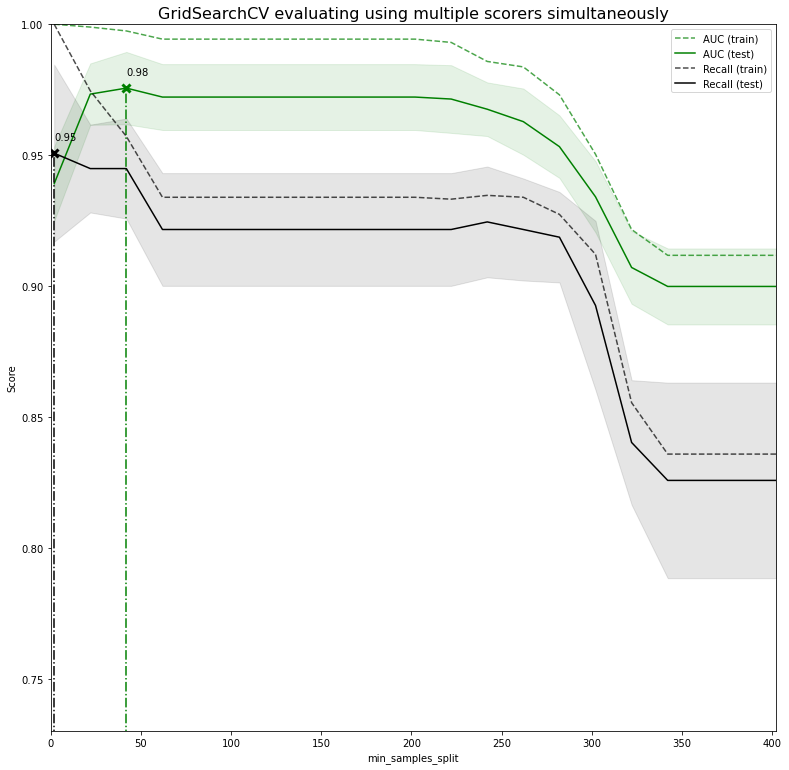

In [414]:
plt.figure(figsize=(13, 13))
plt.title("GridSearchCV evaluating using multiple scorers simultaneously", fontsize=16)

plt.xlabel("min_samples_split")
plt.ylabel("Score")

ax = plt.gca()
ax.set_xlim(0, 402)
ax.set_ylim(0.73, 1)

# Get the regular numpy array from the MaskedArray
X_axis = np.array(results["param_min_samples_split"].data, dtype=float)

for scorer, color in zip(sorted(scoring), ["g", "k"]):
    for sample, style in (("train", "--"), ("test", "-")):
        sample_score_mean = results["mean_%s_%s" % (sample, scorer)]
        sample_score_std = results["std_%s_%s" % (sample, scorer)]
        ax.fill_between(
            X_axis,
            sample_score_mean - sample_score_std,
            sample_score_mean + sample_score_std,
            alpha=0.1 if sample == "test" else 0,
            color=color,
        )
        ax.plot(
            X_axis,
            sample_score_mean,
            style,
            color=color,
            alpha=1 if sample == "test" else 0.7,
            label="%s (%s)" % (scorer, sample),
        )

    best_index = np.nonzero(results["rank_test_%s" % scorer] == 1)[0][0]
    best_score = results["mean_test_%s" % scorer][best_index]

    # Plot a dotted vertical line at the best score for that scorer marked by x
    ax.plot(
        [
            X_axis[best_index],
        ]
        * 2,
        [0, best_score],
        linestyle="-.",
        color=color,
        marker="x",
        markeredgewidth=3,
        ms=8,
    )

    # Annotate the best score for that scorer
    ax.annotate("%0.2f" % best_score, (X_axis[best_index], best_score + 0.005))

plt.legend(loc="best")
plt.grid(False)
plt.show()

In [415]:
gs.best_params_ 

{'min_samples_split': 2}

In [416]:
gs.best_score_ 

0.9507246376811593

In [417]:
y_test_pred = gs.predict(X_test)

In [418]:
print("Test Data Score:\n",clf.score(X_test,y_test)*100)
print("")
print("Classification Report Test:\n",classification_report(y_test,y_test_pred))
print("")
print("Confusion Matrix Test:\n",confusion_matrix(y_test,y_test_pred))

Test Data Score:
 95.94594594594594

Classification Report Test:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       148
           1       0.92      0.94      0.93       148

    accuracy                           0.93       296
   macro avg       0.93      0.93      0.93       296
weighted avg       0.93      0.93      0.93       296


Confusion Matrix Test:
 [[136  12]
 [  9 139]]


In [431]:
recall_score(y_test, y_test_pred, pos_label=1)

0.9391891891891891

In [426]:
y_kkk = gs.predict(X_train)

1.0

## Meu Proprio Experimento

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

In [438]:
recall_1 = make_scorer(recall_score)

In [439]:
scoring = {"AUC": "roc_auc", "Recall": recall_1}

In [443]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [458]:
recall_1_dt = []
hyperparams_dt = []
recall_1_treino_dt = []

for i in range(30):
    kfold = KFold(n_splits = 10, shuffle = True, random_state = i)
    
    gs = GridSearchCV(
        DecisionTreeClassifier(random_state=i),
        param_grid={"min_samples_split": range(2, 403, 200), "max_depth": range(1 , 2, 1)},
        scoring=scoring,
        refit="Recall",
        n_jobs=2,
        return_train_score=True,
        cv = kfold
    )
    #Treinando o modelo com dados de treino de 9 folds e utilizando 1 fold para teste
    gs.fit(X_train, y_train)
    
    
    #Melhores resultados e hiperparâmetros encontrados
    recall_treino = gs.best_score_
    hyperparams = gs.best_params_
    
    #Armazenando os resultados
    recall_1_treino_dt.append(recall_treino)
    hyperparams_dt.append(hyperparams)

    ##Predizendo as classes nos dados de teste, utilizando os melhores parâmetros
    y_test_pred = gs.predict(X_test)
    
    #Calculando o recall da classe 1:
    recall_value = recall_score(y_test, y_test_pred, pos_label=1)
    
    recall_1_dt.append(recall_value)
    
   # kfold = KFold(n_splits = 10, shuffle = True, random_state = i)
    #naive_bayes = GaussianNB()
    #scores = cross_val_score(naive_bayes, X, y, cv = kfold)
    #resultados_naive_bayes_cv_300.append(scores)
    #resultados_naive_bayes_cv.append(scores.mean())

In [459]:
hyperparams_dt

[{'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_depth': 1, 'min_samples_split': 2},
 {'max_dept

In [460]:
recall_1_dt

[0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838,
 0.7837837837837838]

In [461]:
recall_1_treino_dt

[0.8358520437480289,
 0.8229418050164684,
 0.8156979517996954,
 0.8274113955181459,
 0.8255652640338239,
 0.8265810813628651,
 0.8248293790553852,
 0.8173345130354143,
 0.8303646328149474,
 0.8136337601537239,
 0.8257380047778617,
 0.8143669473712294,
 0.8306084274893024,
 0.8247610714588642,
 0.8169708614812654,
 0.8261384798384899,
 0.8162947186648619,
 0.8193801753442109,
 0.8308114873749549,
 0.8232227552146171,
 0.8023230656990219,
 0.8250838305740942,
 0.8256435484744309,
 0.8073873609845595,
 0.8359560989654247,
 0.8248646479009987,
 0.8267413750817825,
 0.8261208114656391,
 0.8198427404129818,
 0.8191594586755876]